In [1]:
# Import des librairies principales
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf


# Imports nécessaires pour construire / sauvegarder / évaluer le modèle
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Rescaling
from tensorflow.keras.layers import BatchNormalization

from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping

from sklearn.metrics import classification_report, confusion_matrix


# Importation de l'utilitaire image_dataset_from_directory de Keras
from keras.utils import image_dataset_from_directory




In [2]:
# Définition des chemins d'accès

rep_img = 'C:\\Users\\Utilisateur\\Documents\\DataScience_images_Especes\\'
rep_model = "C:\\Users\\Utilisateur\\Documents\\DataScience\\avr25cds_reconnaissance_champignons\\models\\"

In [3]:
# Importation de l'utilitaire image_dataset_from_directory de Keras

train_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.30,     # 30% réservé pour val + test
    subset="training",
    seed=42,
    batch_size=64,
    image_size=(224, 224)
)

# Dataset temporaire qui va être divisé en 15% validation et 15% test
temp_ds = image_dataset_from_directory(
    rep_img,
    validation_split=0.30,
    subset="validation",
    seed=42,
    batch_size=64,
    image_size=(224, 224)
)


Found 19216 files belonging to 30 classes.
Using 13452 files for training.
Found 19216 files belonging to 30 classes.
Using 5764 files for validation.


In [4]:
# Découpage du dataset temp en validation + test


temp_size = tf.data.experimental.cardinality(temp_ds).numpy()

val_size = temp_size // 2
test_size = temp_size - val_size

val_ds = temp_ds.take(val_size)
test_ds = temp_ds.skip(val_size)

In [5]:
# Optimisation du pipeline

AUTOTUNE = tf.data.AUTOTUNE   # Optimisation automatique du nombre de fichiers et threads à charger

train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE) # Pour garder en mémoire les images et gagner en vitesse // shuffle pour mélanger les images à chaque epoch pour un meilleur apprentissage
val_ds   = val_ds.cache().prefetch(AUTOTUNE)
test_ds  = test_ds.cache().prefetch(AUTOTUNE)

In [6]:
# Nombre de lot dans l'ensemble d'entraînement
print("Nombre de batch dans train_ds:", train_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de validation
print("Nombre de batch dans val_ds:", val_ds.cardinality().numpy())

# Nombre de lot dans l'ensemble de test
print("Nombre de batch dans test_ds:", test_ds.cardinality().numpy())

Nombre de batch dans train_ds: 211
Nombre de batch dans val_ds: 45
Nombre de batch dans test_ds: 46


In [7]:
# Paramétrage du réseau Dense #


# Définition de l'entrée
inputs_dense = Input(shape=(224, 224, 3))

# Couche de rescaling
normalization_layer  = Rescaling(1./255)(inputs_dense)

# Couche de Flatten
x = Flatten()(normalization_layer)

# Première couche dense
x = Dense(
    units=512, 
    activation="relu", 
    kernel_initializer='he_normal' # apprentissage plus stable et plus rapide que "normal"
)(x)
x = BatchNormalization()(x) # plus robuste

# Deuxième couche dense
x = Dense(
    units=128,              
    activation="relu",
    kernel_initializer='he_normal'
)(x)
x = BatchNormalization()(x)

# Couche de sortie
outputs_dense = Dense(
    units=30,                # égal nombre de target
    activation="softmax", 
    kernel_initializer='glorot_uniform' # meilleur équilibre des gradients que "normal"
)(x)



In [8]:
# Création du modèle

model_dense = Model(inputs=inputs_dense, outputs=outputs_dense)

In [9]:
# Compilation du modèle

model_dense.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy']) # sparse_categorical car variables catégorielles

In [10]:
# Callback pour sauvegarder le modèle
save = ModelCheckpoint(
    rep_model+"DNN_model.h5",
    save_best_only=True, 
    monitor='val_accuracy',
    mode='max'
)

# Callback pour réduire le taux d'apprentissage
reduceLR = ReduceLROnPlateau(
                                    monitor="val_loss",
                                    patience=3,
                                    min_delta=0.01,
                                    factor=0.1, 
                                    cooldown=4)

# Callback pour stopper l'apprentissage quand il ne progresse plus
early_stop = EarlyStopping(
                                patience=5,     # Nombre d'époques sans amélioration avant arrêt
                                min_delta=0.01, 
                                mode='min',
                                monitor='val_loss') # On surveille la perte sur l'ensemble de validation

In [11]:
# Entrainement du modèle

history_model = model_dense.fit(train_ds, 
                          epochs=50,                   
                          validation_data=val_ds,
                          callbacks = [reduceLR, save, early_stop])

Epoch 1/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.0934 - loss: 3.4431

211/211 ━━━━━━━━━━━━━━━━━━━━ 46s 198ms/step - accuracy: 0.0935 - loss: 3.4421 - val_accuracy: 0.1333 - val_loss: 3.2256 - learning_rate: 0.0010
Epoch 2/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.2458 - loss: 2.7649

211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 195ms/step - accuracy: 0.2458 - loss: 2.7647 - val_accuracy: 0.1497 - val_loss: 3.1758 - learning_rate: 0.0010
Epoch 3/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 190ms/step - accuracy: 0.3648 - loss: 2.3352 - val_accuracy: 0.1097 - val_loss: 3.7135 - learning_rate: 0.0010
Epoch 4/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.4561 - loss: 1.9600

211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 195ms/step - accuracy: 0.4560 - loss: 1.9601 - val_accuracy: 0.1531 - val_loss: 3.8948 - learning_rate: 0.0010
Epoch 5/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 190ms/step - accuracy: 0.5492 - loss: 1.6304 - val_accuracy: 0.1497 - val_loss: 4.2360 - learning_rate: 0.0010
Epoch 6/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.6583 - loss: 1.2687

211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 195ms/step - accuracy: 0.6584 - loss: 1.2683 - val_accuracy: 0.3938 - val_loss: 2.8171 - learning_rate: 1.0000e-04
Epoch 7/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.7508 - loss: 0.9818

...

211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 193ms/step - accuracy: 0.7958 - loss: 0.8397 - val_accuracy: 0.4358 - val_loss: 2.2701 - learning_rate: 1.0000e-04
Epoch 9/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 185ms/step - accuracy: 0.8236 - loss: 0.7458

211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 192ms/step - accuracy: 0.8236 - loss: 0.7458 - val_accuracy: 0.4528 - val_loss: 2.2200 - learning_rate: 1.0000e-04
Epoch 10/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 190ms/step - accuracy: 0.8594 - loss: 0.6334 - val_accuracy: 0.4479 - val_loss: 2.2632 - learning_rate: 1.0000e-04
Epoch 11/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 40s 191ms/step - accuracy: 0.8849 - loss: 0.5529 - val_accuracy: 0.4514 - val_loss: 2.3482 - learning_rate: 1.0000e-04
Epoch 12/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9087 - loss: 0.4756

211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 195ms/step - accuracy: 0.9087 - loss: 0.4756 - val_accuracy: 0.4569 - val_loss: 2.3756 - learning_rate: 1.0000e-04
Epoch 13/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step - accuracy: 0.9395 - loss: 0.3874

211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 193ms/step - accuracy: 0.9395 - loss: 0.3873 - val_accuracy: 0.4712 - val_loss: 2.2476 - learning_rate: 1.0000e-05
Epoch 14/50
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step - accuracy: 0.9476 - loss: 0.3574

211/211 ━━━━━━━━━━━━━━━━━━━━ 41s 194ms/step - accuracy: 0.9476 - loss: 0.3574 - val_accuracy: 0.4785 - val_loss: 2.2452 - learning_rate: 1.0000e-05


In [12]:
np.save(rep_model+"DNN_model_history.npy", history_model.history)

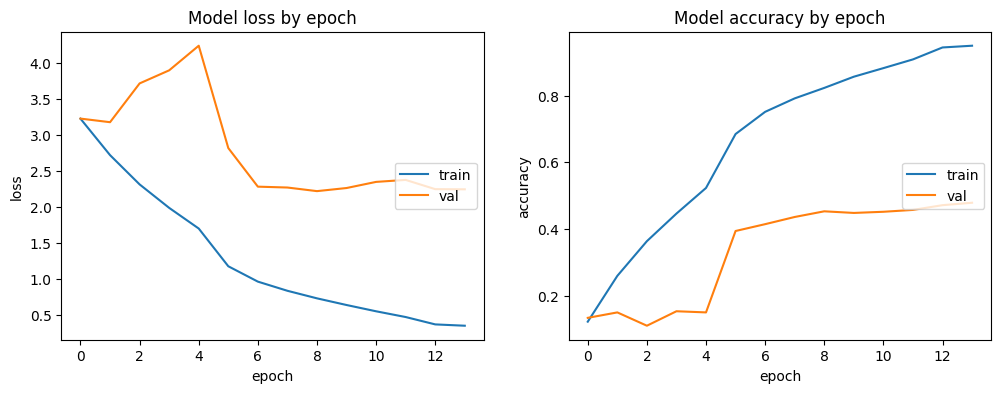

In [13]:
plt.figure(figsize=(12,4))

plt.subplot(121)
plt.plot(history_model.history['loss'])
plt.plot(history_model.history['val_loss'])
plt.title('Model loss by epoch')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='right')

plt.subplot(122)
plt.plot(history_model.history['accuracy'])
plt.plot(history_model.history['val_accuracy'])
plt.title('Model accuracy by epoch')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='right')
plt.show()

In [14]:
# Fonction pour obtenir les prédictions

def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:
        
        preds = model_dense.predict(images, verbose=0)
        pred_labels.extend(np.argmax(preds, axis=-1))

        true_labels.extend(labels.numpy())

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds)

# Affichage du rapport de classification
print(classification_report(y_true, y_pred))



              precision    recall  f1-score   support

           0       0.91      0.87      0.89        68
           1       0.16      0.10      0.12        89
           2       0.31      0.21      0.25       154
           3       0.21      0.22      0.22       130
           4       0.11      0.10      0.11        98
           5       0.16      0.12      0.13       104
           6       0.90      1.00      0.95        84
           7       0.20      0.21      0.20       152
           8       0.75      0.87      0.80        76
           9       0.55      0.56      0.55        73
          10       0.29      0.27      0.28       146
          11       0.84      0.86      0.85        79
          12       0.67      0.62      0.65        66
          13       0.16      0.20      0.18       148
          14       0.60      0.59      0.60        71
          15       0.68      0.58      0.63        77
          16       0.64      0.70      0.67        80
          17       0.72    

<Axes: >

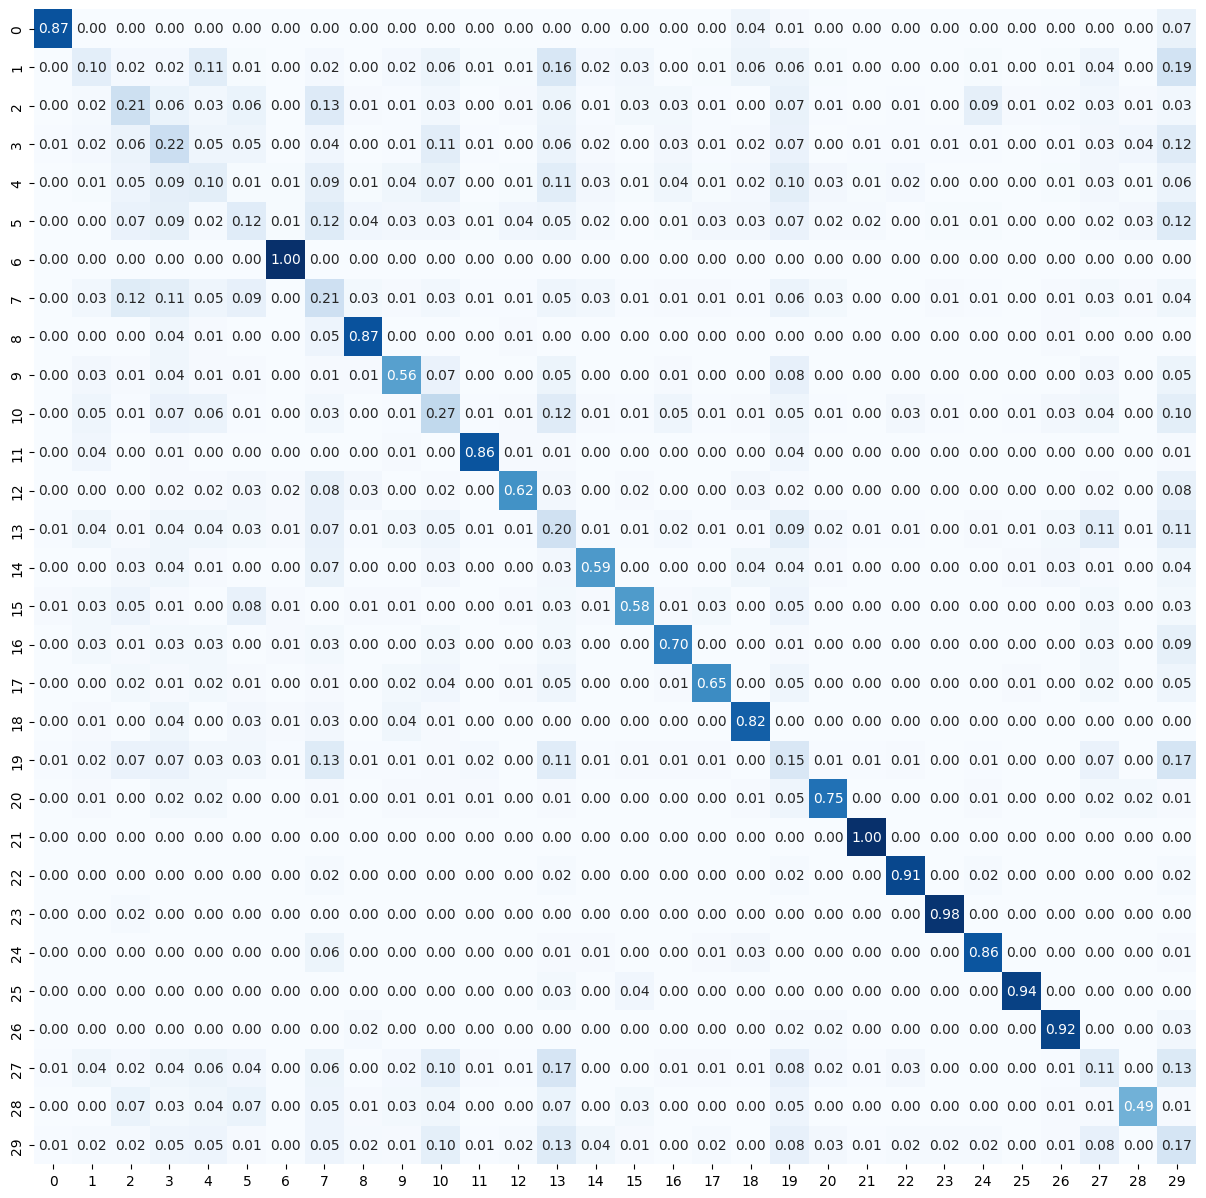

In [15]:
# Affichage de la matrice de confusion

plt.figure(figsize=(15, 15))
cnf_matrix = confusion_matrix(y_true, y_pred, normalize='true')
sns.heatmap(cnf_matrix, cmap='Blues', annot=True, cbar=False, fmt=".2f")

In [16]:
print("Le modèle overfit. Il faut passer sur un CNN.")

Le modèle overfit. Il faut passer sur un CNN.
